In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')

print(deliveries_df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [22]:
def calculate_partnerships_for_group(inning_df):
    partnerships_data = []
    current_batsman_pair = (None, None)
    current_partnership_runs = 0

    inning_df = inning_df.sort_values(by=['over', 'ball'])

    for _, row in inning_df.iterrows():

        batsman = row['batter']
        non_striker = row['non_striker']
        total_runs_this_ball = row['total_runs']


        active_batsmen_on_this_ball = tuple(sorted([batsman, non_striker]))


        if current_batsman_pair == (None, None) or active_batsmen_on_this_ball != current_batsman_pair:

            if current_partnership_runs > 0 and current_batsman_pair != (None, None):
                partnerships_data.append({
                    'match_id': row['match_id'],
                    'inning': row['inning'],
                    'batsman1': current_batsman_pair[0],
                    'batsman2': current_batsman_pair[1],
                    'partnership_runs': current_partnership_runs
                })


            current_batsman_pair = active_batsmen_on_this_ball
            current_partnership_runs = total_runs_this_ball
        else:

            current_partnership_runs += total_runs_this_ball


    if current_partnership_runs > 0 and current_batsman_pair != (None, None):

        last_row = inning_df.iloc[-1]
        partnerships_data.append({
            'match_id': last_row['match_id'],
            'inning': last_row['inning'],
            'batsman1': current_batsman_pair[0],
            'batsman2': current_batsman_pair[1],
            'partnership_runs': current_partnership_runs
        })

    return pd.DataFrame(partnerships_data)

all_partnerships = deliveries_df.groupby(['match_id', 'inning'], group_keys=False).apply(calculate_partnerships_for_group)

print("First 5 calculated partnerships:")
display(all_partnerships.head())

First 5 calculated partnerships:


/tmp/ipykernel_3978/3496940324.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_partnerships = deliveries_df.groupby(['match_id', 'inning'], group_keys=False).apply(calculate_partnerships_for_group)


,match_id,inning,batsman1,batsman2,partnership_runs
0,335982,1,BB McCullum,SC Ganguly,61
1,335982,1,BB McCullum,RT Ponting,51
2,335982,1,BB McCullum,DJ Hussey,60
3,335982,1,BB McCullum,Mohammad Hafeez,50
0,335982,2,R Dravid,W Jaffer,4


In [23]:
highest_partnership_per_match = all_partnerships.loc[all_partnerships.groupby('match_id')['partnership_runs'].idxmax()]

print("Highest partnership for each match (first 5):")
display(highest_partnership_per_match[['match_id', 'inning', 'batsman1', 'batsman2', 'partnership_runs']].head())

Highest partnership for each match (first 5):


,match_id,inning,batsman1,batsman2,partnership_runs
0,335982,1,BB McCullum,SC Ganguly,61
0,335982,2,R Dravid,W Jaffer,4
0,335983,1,ML Hayden,PA Patel,26
0,335983,2,JR Hopes,K Goel,56
0,335984,1,T Kohli,YK Pathan,17


In [24]:
highest_partnership_row = all_partnerships.sort_values(by='partnership_runs', ascending=False).iloc[0]

print("\nOverall Highest Partnership:")
print(f"  Runs: {highest_partnership_row['partnership_runs']}")
print(f"  Batsmen: {highest_partnership_row['batsman1']} and {highest_partnership_row['batsman2']}")
print(f"  Match ID: {highest_partnership_row['match_id']}, Inning: {highest_partnership_row['inning']}")


Overall Highest Partnership:
  Runs: 229
  Batsmen: AB de Villiers and V Kohli
  Match ID: 980987, Inning: 1


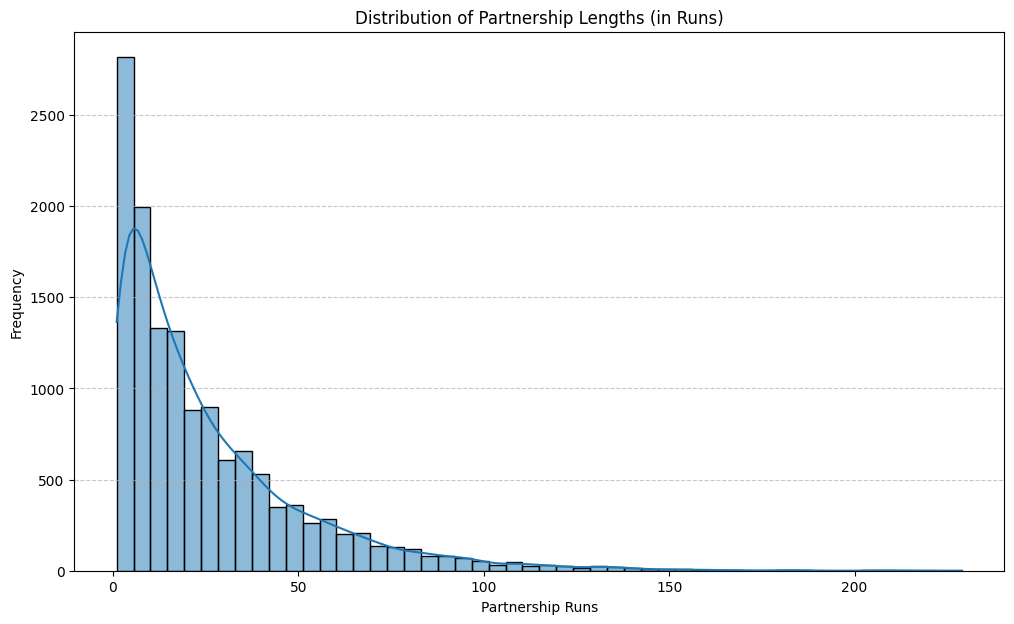

In [25]:
plt.figure(figsize=(12, 7))
sns.histplot(all_partnerships['partnership_runs'], bins=50, kde=True)
plt.title('Distribution of Partnership Lengths (in Runs)')
plt.xlabel('Partnership Runs')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()